In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import math
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d

# 1. Inspect Data

In [2]:
set_config(transform_output="pandas")

train_data = pd.read_csv("./dataset/train.csv")
test_data = pd.read_csv("./dataset/test.csv")


In [3]:
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()

In [4]:
train_data_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
train_data_copy.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Print out the unique data each column contains
for col_name, data in train_data_copy.items():
    print(f"{col_name}: {pd.unique(data)}")

PassengerId: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 2

In [7]:
def bar_plot_values_count(col_not_to_include, df):
    desired_col = df.columns.difference(col_not_to_include)

    # Plot each predictor variable against survived
    for predictor, s in df[desired_col].items():
        predictor_df = df[[predictor, "Survived"]].groupby(predictor).value_counts()
        predictor_df = predictor_df.reset_index([0,1])

        sb.barplot(predictor_df, x=predictor, y="count", hue="Survived")
        plt.show()

        print(predictor_df.sort_values(by="count", ascending=False).head(n = 20))

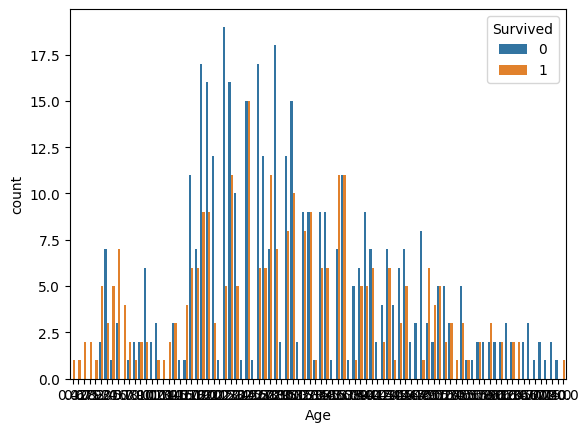

     Age  Survived  count
43  21.0         0     19
59  28.0         0     18
36  18.0         0     17
53  25.0         0     17
38  19.0         0     16
45  22.0         0     16
64  30.0         0     15
50  24.0         0     15
51  24.0         1     15
40  20.0         0     12
55  26.0         0     12
62  29.0         0     12
32  16.0         0     11
46  22.0         1     11
57  27.0         1     11
78  35.0         1     11
80  36.0         1     11
81  36.0         0     11
65  30.0         1     10
47  23.0         0     10


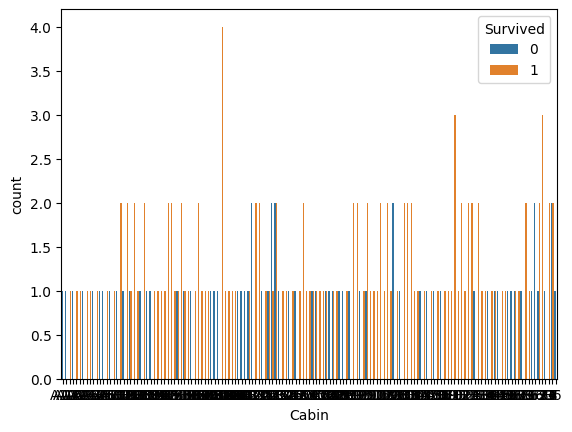

               Cabin  Survived  count
50           B96 B98         1      4
157              F33         1      3
128             E101         1      3
78               C52         1      2
25               B35         1      2
110              D26         0      2
43               B77         1      2
106              D17         1      2
70       C23 C25 C27         0      2
69       C23 C25 C27         1      2
32               B49         1      2
101                D         1      2
33                B5         1      2
135              E33         1      2
108              D20         1      2
133              E25         1      2
37   B57 B59 B63 B66         1      2
132              E24         1      2
67           C22 C26         0      2
22               B28         1      2


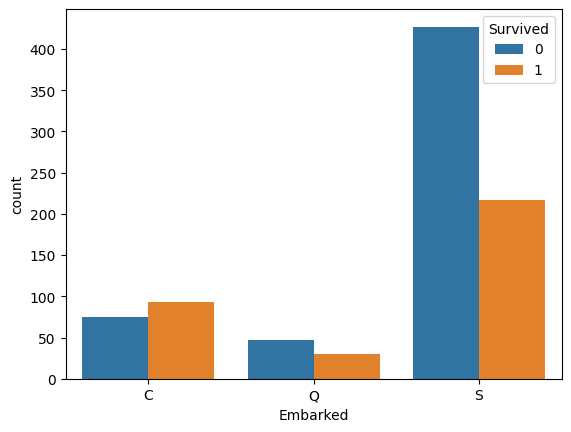

  Embarked  Survived  count
4        S         0    427
5        S         1    217
0        C         1     93
1        C         0     75
2        Q         0     47
3        Q         1     30


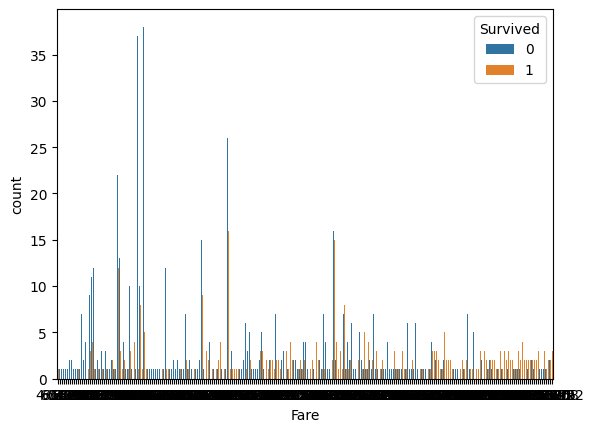

        Fare  Survived  count
60    8.0500         0     38
55    7.8958         0     37
109  13.0000         0     26
40    7.7500         0     22
110  13.0000         1     16
177  26.0000         0     16
94   10.5000         0     15
178  26.0000         1     15
0     0.0000         0     14
42    7.7750         0     13
72    8.6625         0     12
41    7.7500         1     12
22    7.2500         0     12
20    7.2292         0     11
50    7.8542         0     10
57    7.9250         0     10
95   10.5000         1      9
18    7.2250         0      9
184  26.5500         1      8
58    7.9250         1      8


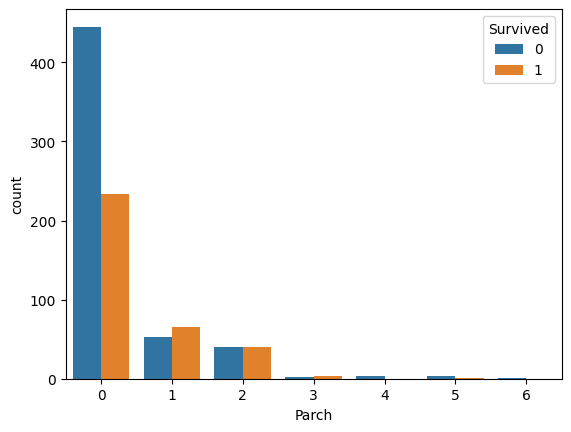

    Parch  Survived  count
0       0         0    445
1       0         1    233
2       1         1     65
3       1         0     53
4       2         1     40
5       2         0     40
8       4         0      4
9       5         0      4
6       3         1      3
7       3         0      2
10      5         1      1
11      6         0      1


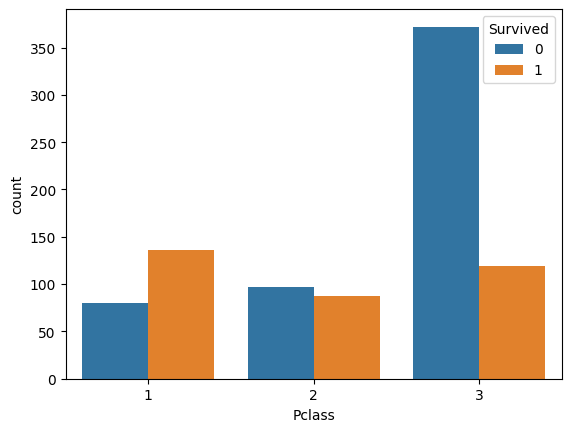

   Pclass  Survived  count
4       3         0    372
0       1         1    136
5       3         1    119
2       2         0     97
3       2         1     87
1       1         0     80


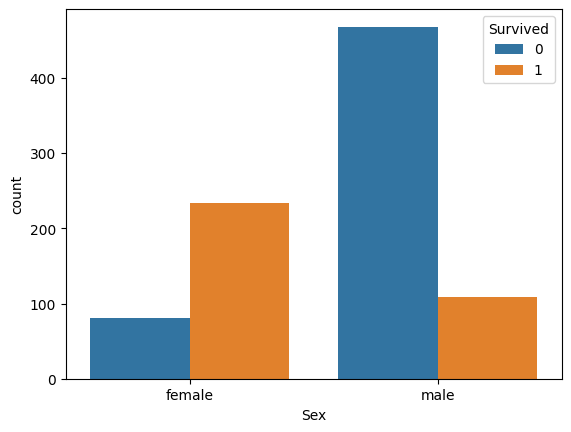

      Sex  Survived  count
2    male         0    468
0  female         1    233
3    male         1    109
1  female         0     81


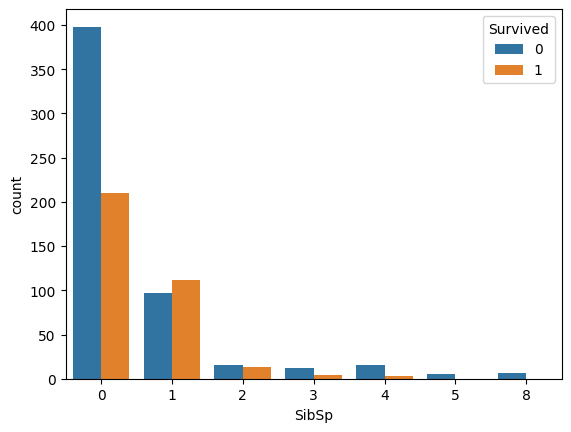

    SibSp  Survived  count
0       0         0    398
1       0         1    210
2       1         1    112
3       1         0     97
4       2         0     15
8       4         0     15
5       2         1     13
6       3         0     12
11      8         0      7
10      5         0      5
7       3         1      4
9       4         1      3


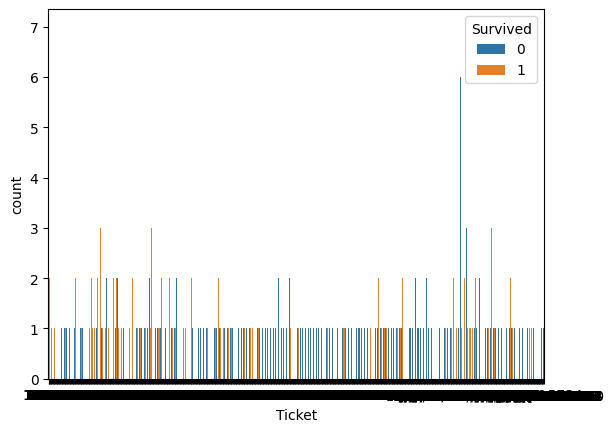

           Ticket  Survived  count
357        347082         0      7
603      CA. 2343         0      7
361        347088         0      6
271       3101295         0      6
601       CA 2144         0      6
667  S.O.C. 14879         0      5
510        382652         0      5
87           1601         1      5
419        349909         0      4
34         113760         1      4
213          2666         1      4
724    W./C. 6608         0      4
518          4133         0      4
352        347077         1      3
368        347742         1      3
610          LINE         0      3
257         29106         1      3
149        239853         0      3
626      PC 17572         1      3
649      PC 17755         1      3


In [8]:
col_not_to_include = ["PassengerId", "Survived", "Name"]
bar_plot_values_count(col_not_to_include, train_data_copy)


### 1.1 Observations

- Age: The overall population is centered around their 20s - 30s.
- Cabin: Not very useful but can be feature engineered
- Embarked: Strong bias to not surviving if you embarked from Southampton.
    - What's the Pclass composition of people who embarked from Southhampton?
- Fare: If you had cheap fares then you are more likely to die.
- Parch: If you had no children/parents you were more likely to die.
    - Is there overlap for gender and people who traveled alone?
- Pclass: If you are higher in socio-economic status then you were more likely to survive.
    - Some discussions mentioned the possibility 
- Sex: If you were male your chances were low whereas if you were female then you have a higher chance
    - Makes sense considering — assumption based on the movie — children and women were given priority to board first.
- SibSp: Almost identical to Pclass.
    - Assumption here is that 1. of the people who have no parent/children also didn't have siblings (i.e travelled alone) 2. Families have a greater chance of surviving collectively
- Ticket: Needs to be feature engineered.

# 2. Clean/Preprocess Data

## 2.1 Defining the Problem

**Is this a classification or regression problem?** 

This is a binary classification problem since we need to predict survival based on provided test data.

**What model should you use?**

Some research — [geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/comprehensive-guide-to-classification-models-in-scikit-learn/) and [bytescrum](https://blog.bytescrum.com/a-comprehensive-guide-to-binary-classification-in-machine-learning) — for classification I've deduced it down to:

- K-Nearest Neighbors (KNN)
    - classifies data based on distance — some features fit into nice buckets so intuitively makes sense to me.
    - easy to implement
- Random Forest
    - "combines multiple decision trees to improve the model's accuracy and robustness"
    - having both categorical data and numerical, an ensemble method would be strong in identifying the subsets

**Implementation**

I am going to experiemnt with both models and tweak things around. Get a baseline performance and then try to see if I can optimize or feature engineer to get better results. 


## 2.2 Missing Data

1. Age has a lot of missing data based on the count from above. `.dropna` is my first approach to handling missing data which is the easiest to get started with. UPDATE - This is not valid as the submission requires all the rows to be present
2. Instead I will impute using mean base on this [Geeks for Geeks Article](https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/)

In [27]:
train_data_copy.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
train_data_copy.fillna({"Age": train_data_copy["Age"].mean()}, inplace=True)
test_data_copy.fillna({"Age": test_data_copy["Age"].mean()}, inplace=True)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Predicted
0,892,0.873482,"Kelly, Mr. James",-0.755929,0.334993,0,0,330911,7.8292,NaN,Q,0
1,893,0.873482,"Wilkes, Mrs. James (Ellen Needs)",1.322876,1.325530,1,0,363272,7.0000,NaN,S,0
2,894,-0.315819,"Myles, Mr. Thomas Francis",-0.755929,2.514175,0,0,240276,9.6875,NaN,Q,0
3,895,0.873482,"Wirz, Mr. Albert",-0.755929,-0.259330,0,0,315154,8.6625,NaN,S,0
4,896,0.873482,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1.322876,-0.655545,1,1,3101298,12.2875,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0.873482,"Spector, Mr. Woolf",-0.755929,0.000000,0,0,A.5. 3236,8.0500,NaN,S,0
414,1306,-1.505120,"Oliva y Ocana, Dona. Fermina",1.322876,0.691586,0,0,PC 17758,108.9000,C105,C,1
415,1307,0.873482,"Saether, Mr. Simon Sivertsen",-0.755929,0.651965,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,1308,0.873482,"Ware, Mr. Frederick",-0.755929,0.000000,0,0,359309,8.0500,NaN,S,0


## 2.3 Label Encoding

I plan on using sex predictor variable in my model to I assign each category with an integer. 


In [11]:
train_data_copy["Sex"] = train_data_copy["Sex"].replace({
    "male" : 0,
    "female" : 1
})

test_data_copy["Sex"] = test_data_copy["Sex"].replace({
    "male" : 0,
    "female" : 1
})


## 2.4 Scale Data

I am going to use KNN to make predictions. I need to scale it since the model uses distance calculations based on the predictor variables, scaling it ensures that the calcution isn't biased towards any one predictor variable with a large scale.

In [12]:
scaler = StandardScaler()

features = ["Sex", "Pclass", "Age"]

train_data_copy[features] = scaler.fit_transform(train_data_copy[features])
test_data_copy[features] = scaler.fit_transform(test_data_copy[features])


## 3. Visualize Training Data

3D Plots derived from [UofT DSI Github examples](https://github.com/UofT-DSI/LCR/blob/main/01_materials/notebooks/Classification-1.ipynb)

<module 'matplotlib.pyplot' from '/Users/stevenhan/Documents/Learning/Data Science Foundations/Github/learn-predict-repeat/my_virtual_env/lib/python3.13/site-packages/matplotlib/pyplot.py'>

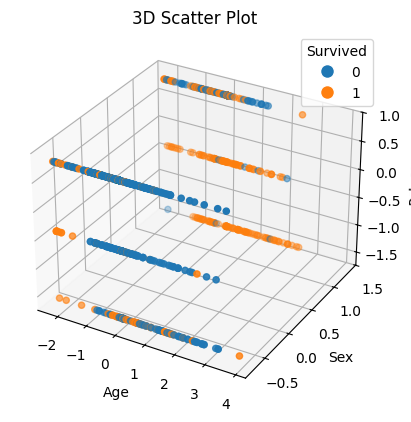

In [13]:
# Create mapping between values and colors
labels = train_data_copy["Survived"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(train_data_copy['Age'], train_data_copy['Sex'], train_data_copy['Pclass'], 
                  c=train_data_copy['Survived'].map(color_map), marker='o')

# Add axis labels
ax.set_xlabel('Age')
ax.set_ylabel('Sex')
ax.set_zlabel('Pclass')
ax.set_title('3D Scatter Plot')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add legend
plt.legend(handles=handles, title='Survived')

# Show plot
plt


# Run K-Nearest Neighbor Classifier

This data set does not provide the test response variable so I won't be able to optimize for the hyper parameter `n_nieghbors`. I can do this manually — run, check, adjust, repeat. Which is exactly what I ended up doing.

| n_neighbors | Score |
| --- | --- |
| 5 | 0.73205 |
| 7 | 0.73923 |
| 9 | 0.75119 |
| 11 | 0.74641 |

This shows 9 n_neighbors has the best result but this score is lower than the gendered_submission — from the [tutorial by Alexis](https://www.kaggle.com/code/alexisbcook/titanic-tutorial) — which scored 0.77511

In [14]:
knn = KNeighborsClassifier(n_neighbors= 9)

X_train = train_data_copy[features]
y_train = train_data_copy["Survived"]

knn.fit(X=X_train, y=y_train)
test_data_copy["Predicted"] = knn.predict(test_data_copy[features])



In [15]:
output = pd.DataFrame({'PassengerId': test_data_copy.PassengerId, 'Survived': test_data_copy.Predicted})
output.to_csv('submission.csv', index=False)

# Visualize Predicted Test Data

<module 'matplotlib.pyplot' from '/Users/stevenhan/Documents/Learning/Data Science Foundations/Github/learn-predict-repeat/my_virtual_env/lib/python3.13/site-packages/matplotlib/pyplot.py'>

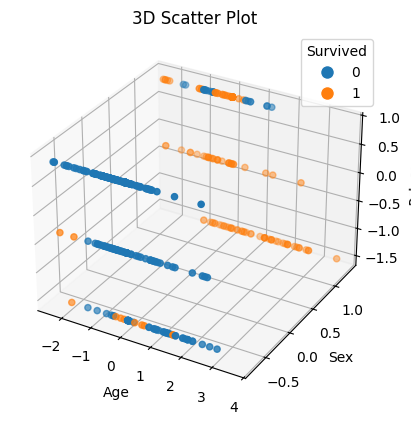

In [16]:
# Create mapping between values and colors
labels = test_data_copy["Predicted"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(test_data_copy['Age'], test_data_copy['Sex'], test_data_copy['Pclass'], 
                  c=test_data_copy['Predicted'].map(color_map), marker='o')

# Add axis labels
ax.set_xlabel('Age')
ax.set_ylabel('Sex')
ax.set_zlabel('Pclass')
ax.set_title('3D Scatter Plot')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
           for label in labels]

# Add legend
plt.legend(handles=handles, title='Survived')

# Show plot
plt


# V2 - Feature Engineering

Using Age, Sex, Pclass as the initial features provided as easy start but now I'd like to dive deeper and see if I can include the other remaining predictor variables or feature engineer some new ones.

Features have been copied from [Jawad Hussain's post](https://www.kaggle.com/competitions/titanic/discussion/569015) about feature engineering.

In [17]:
# feature engineering
train_data_copy['Title'] = train_data_copy['Name'].str.extract(' ([A-Za-z]+).', expand=False)
train_data_copy['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
train_data_copy['IsAlone'] = (train_data_copy['FamilySize'] == 1).astype(int)
train_data_copy['FareBin'] = pd.qcut(train_data_copy['Fare'], 4, labels=[1, 2, 3, 4])
train_data_copy['CabinLetter'] = train_data_copy['Cabin'].astype(str).str[0]


# Inspect data
for col_name, data in train_data_copy[['Title', 'FamilySize', 'IsAlone', 'FareBin', 'CabinLetter']].items():
    print(f"{col_name}: {pd.unique(data)}")

Title: <StringArray>
[         'Mr',         'Mrs',        'Miss',      'Master',      'Planke',
         'Don',         'Rev',    'Billiard',         'der',       'Walle',
          'Dr',  'Pelsmaeker',      'Mulder',           'y',       'Steen',
       'Carlo',         'Mme',        'Impe',          'Ms',       'Major',
      'Gordon', 'Messemaeker',        'Mlle',         'Col',        'Capt',
       'Velde',         'the',      'Shawah',    'Jonkheer',   'Melkebeke',
    'Cruyssen']
Length: 31, dtype: str
FamilySize: [ 2  1  5  3  7  6  4  8 11]
IsAlone: [0 1]
FareBin: [1, 4, 2, 3]
Categories (4, int64): [1 < 2 < 3 < 4]
CabinLetter: <StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str


### Visualize each column vs 'survived'



     Age  Survived  count
43  21.0         0     19
59  28.0         0     18
36  18.0         0     17
53  25.0         0     17
38  19.0         0     16
45  22.0         0     16
64  30.0         0     15
50  24.0         0     15
51  24.0         1     15
40  20.0         0     12
55  26.0         0     12
62  29.0         0     12
32  16.0         0     11
46  22.0         1     11
57  27.0         1     11
78  35.0         1     11
80  36.0         1     11
81  36.0         0     11
65  30.0         1     10
47  23.0         0     10


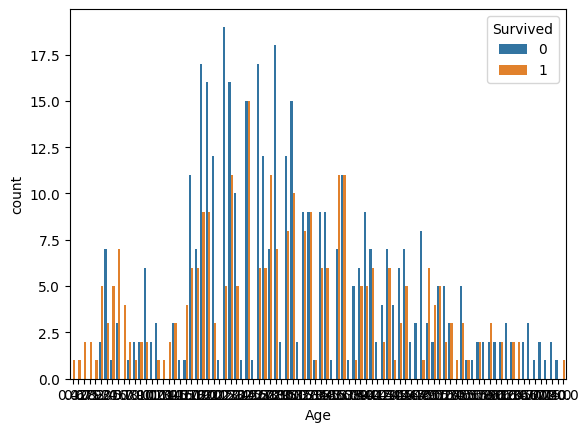

               Cabin  Survived  count
50           B96 B98         1      4
157              F33         1      3
128             E101         1      3
78               C52         1      2
25               B35         1      2
110              D26         0      2
43               B77         1      2
106              D17         1      2
70       C23 C25 C27         0      2
69       C23 C25 C27         1      2
32               B49         1      2
101                D         1      2
33                B5         1      2
135              E33         1      2
108              D20         1      2
133              E25         1      2
37   B57 B59 B63 B66         1      2
132              E24         1      2
67           C22 C26         0      2
22               B28         1      2


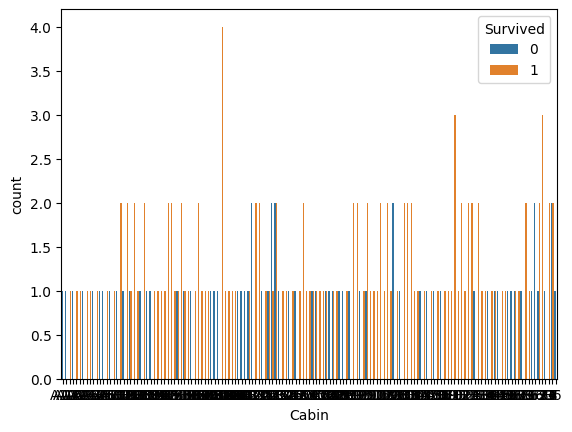

  Embarked  Survived  count
4        S         0    427
5        S         1    217
0        C         1     93
1        C         0     75
2        Q         0     47
3        Q         1     30


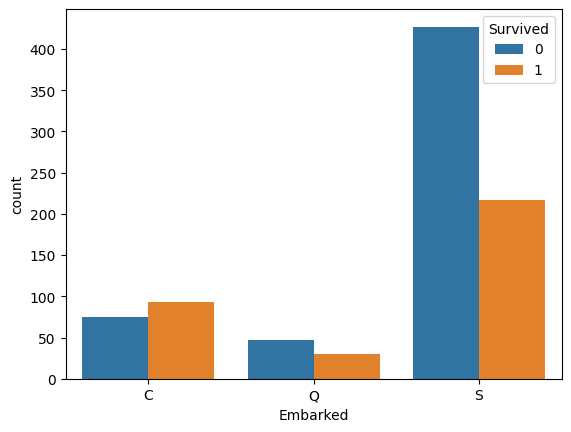

        Fare  Survived  count
60    8.0500         0     38
55    7.8958         0     37
109  13.0000         0     26
40    7.7500         0     22
110  13.0000         1     16
177  26.0000         0     16
94   10.5000         0     15
178  26.0000         1     15
0     0.0000         0     14
42    7.7750         0     13
72    8.6625         0     12
41    7.7500         1     12
22    7.2500         0     12
20    7.2292         0     11
50    7.8542         0     10
57    7.9250         0     10
95   10.5000         1      9
18    7.2250         0      9
184  26.5500         1      8
58    7.9250         1      8


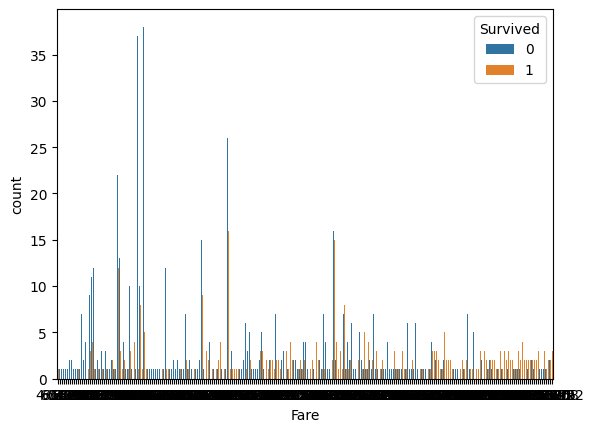

    Parch  Survived  count
0       0         0    445
1       0         1    233
2       1         1     65
3       1         0     53
4       2         1     40
5       2         0     40
8       4         0      4
9       5         0      4
6       3         1      3
7       3         0      2
10      5         1      1
11      6         0      1


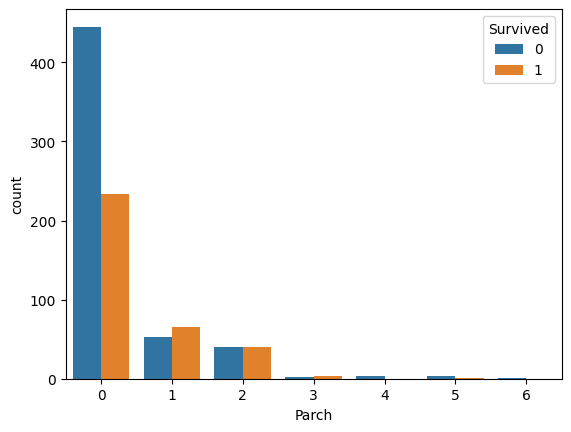

   Pclass  Survived  count
4       3         0    372
0       1         1    136
5       3         1    119
2       2         0     97
3       2         1     87
1       1         0     80


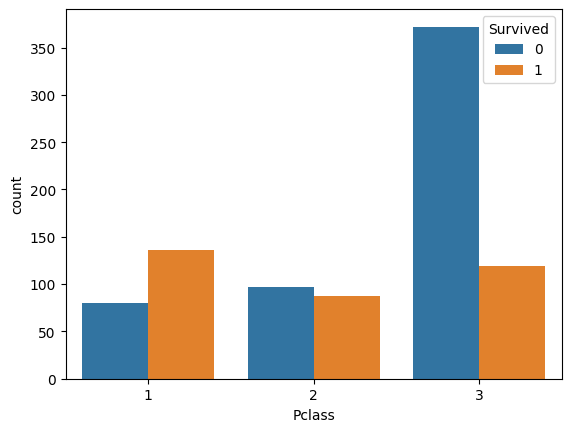

      Sex  Survived  count
2    male         0    468
0  female         1    233
3    male         1    109
1  female         0     81


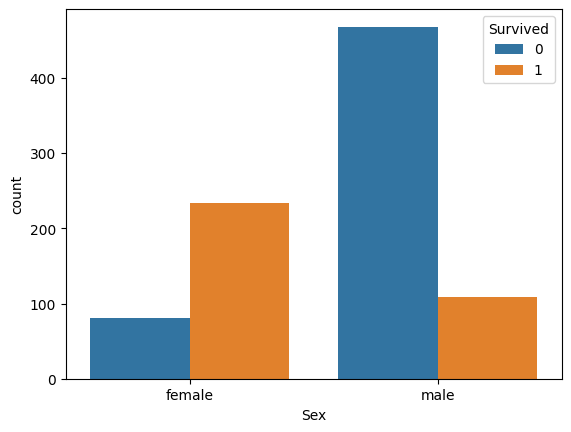

    SibSp  Survived  count
0       0         0    398
1       0         1    210
2       1         1    112
3       1         0     97
4       2         0     15
8       4         0     15
5       2         1     13
6       3         0     12
11      8         0      7
10      5         0      5
7       3         1      4
9       4         1      3


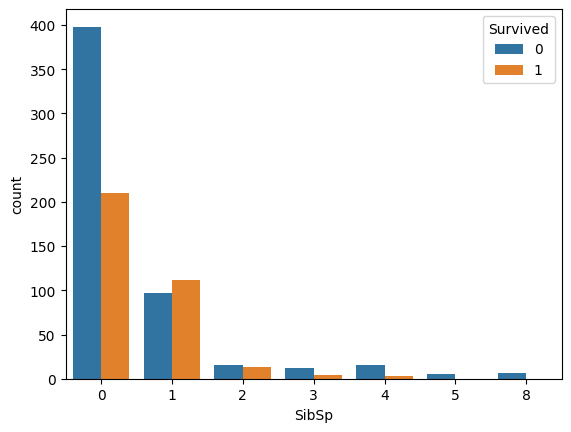

           Ticket  Survived  count
357        347082         0      7
603      CA. 2343         0      7
361        347088         0      6
271       3101295         0      6
601       CA 2144         0      6
667  S.O.C. 14879         0      5
510        382652         0      5
87           1601         1      5
419        349909         0      4
34         113760         1      4
213          2666         1      4
724    W./C. 6608         0      4
518          4133         0      4
352        347077         1      3
368        347742         1      3
610          LINE         0      3
257         29106         1      3
149        239853         0      3
626      PC 17572         1      3
649      PC 17755         1      3


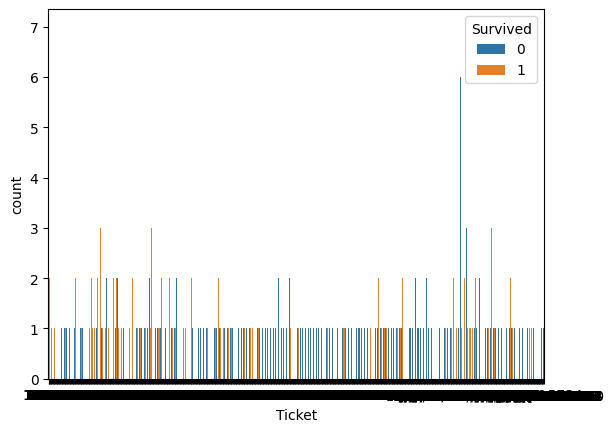

In [ ]:
col_not_to_include = ["PassengerId", "Survived", "Name"]
train_data_copy = train_data.copy()
desired_col = train_data_copy.columns.difference(col_not_to_include)

# Plot each predictor variable against survived
for predictor, s in train_data_copy[desired_col].items():
    predictor_df = train_data_copy[[predictor, "Survived"]].groupby(predictor).value_counts()

    predictor_df = predictor_df.reset_index([0,1])

    # Tells me which values had the highest counts
    print(predictor_df.sort_values(by='count', ascending=False).head(n=20))
    
    sb.barplot(predictor_df, x=predictor, y="count", hue="Survived")
    plt.show()



# Questions/Thoughts
- Title is huge spike
    - what title is that spike - Mr. at 423
- select features based on these graphs
    - how to determine relevance of feature in a more statistical way
        - I think for KNN intuitively the data needs to bias? or have majority in their repsective buckets 
        - if everything is 50/50 then no real value in including it
        - for many number of buckets you might have large percentage but low overall impact
            - e.g. 4:1 survivorship is 80% survival rate but incontext to a sample size of few hundreds it then becomes insignificant.
            - come up with a formula that can achieve this meaning or weight to each outcome - or reasearch if there is an existing method to    this 
    - Claude Ai - has pointed me to Chi-squared for p-value and Cramér's V for effect size


In [19]:
title = train_data_copy[["Title", "Survived"]].groupby("Title").value_counts()
title

KeyError: "['Title'] not in index"

In [ ]:
knn = KNeighborsClassifier(n_neighbors= 9)

features2 = [""]
X_train = train_data_copy[features]

y_train = train_data_copy["Survived"]

knn.fit(X=X_train, y=y_train)
test_data_copy["Predicted"] = knn.predict(test_data_copy[features])

